In [ ]:
!unzip "/content/drive/MyDrive/DATASETS/skin_assesment_dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: skin_assesment_dataset/Scabies/aug_247_cutaneous-Larva-Migrans-11.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_248_biting-insects-42.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_248_scabies-116.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_249_scabies-180.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_249_tick-bite-30.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_24_cactus-granuloma-2.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_24_pubic-lice-52.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_250_pediculosis-lids-2.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_250_scabies-80.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_251_lyme-disease-3.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_251_tick-bite-32.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_252_biting-insects-24.jpg  
  inflating: skin_assesment_dataset/Scabies/aug_252_spider-bite-

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Input,Conv2D,MaxPool2D,Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
import pathlib

In [ ]:
DATA_DIR = "/content/skin_assesment_dataset"
EPOCHS = 50
IMG_SIZE = (224,224,3)
BATCH_SIZE = 32

In [ ]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE[:2],
    batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE[:2],
    batch_size=BATCH_SIZE
)

Found 17856 files belonging to 16 classes.
Using 14285 files for training.
Found 17856 files belonging to 16 classes.
Using 3571 files for validation.


In [ ]:
class_name = train_ds.class_names
class_name

['Eczema',
 'Herpes',
 'Impetigo',
 'Psoriasis',
 'Rashes',
 'Ringworm',
 'Rosacea',
 'Scabies',
 'Vitiligo',
 'acne',
 'cellulitis',
 'dark_spots or Hyperpigmentation',
 'normal',
 'skin_cancer',
 'urticaria_hives',
 'wrinkle']

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B3

In [ ]:
efficientnet_base = EfficientNetV2B3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
model_efficientnet = Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),
    efficientnet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_name), activation='softmax')
])

In [ ]:
efficientnet_base.trainable = False

In [ ]:
model_efficientnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_efficientnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 7, 7, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,129,422 (50.08 MB)

 Trainable params: 198,800 (776.56 KB)

 Non-trainable params: 12,930,622 (49.33 MB)

In [ ]:
history = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35
)

Epoch 1/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 100s 171ms/step - accuracy: 0.2786 - loss: 2.2894 - val_accuracy: 0.4889 - val_loss: 1.7682
Epoch 2/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 70s 156ms/step - accuracy: 0.4555 - loss: 1.7081 - val_accuracy: 0.5587 - val_loss: 1.4523
Epoch 3/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 82s 157ms/step - accuracy: 0.5168 - loss: 1.4992 - val_accuracy: 0.5945 - val_loss: 1.3025
Epoch 4/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 90s 174ms/step - accuracy: 0.5527 - loss: 1.3840 - val_accuracy: 0.6180 - val_loss: 1.2126
Epoch 5/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 78s 175ms/step - accuracy: 0.5742 - loss: 1.3096 - val_accuracy: 0.6351 - val_loss: 1.1452
Epoch 6/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 69s 155ms/step - accuracy: 0.5903 - loss: 1.2592 - val_accuracy: 0.6472 - val_loss: 1.1030
Epoch 7/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 70s 156ms/step - accuracy: 0.6018 - loss: 1.2132 - val_accuracy: 0.6547 - val_loss: 1.0737
Epoch 8/35
447/447 ━━━━━━━━━━━━━━━━━━━━ 70s 157ms/step - accuracy: 0.6166 - loss: 

In [ ]:
efficientnet_base.trainable = True

In [ ]:
model_efficientnet.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_efficientnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 7, 7, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,129,422 (50.08 MB)

 Trainable params: 13,020,206 (49.67 MB)

 Non-trainable params: 109,216 (426.62 KB)

In [ ]:
history_fine_tune = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=35
)

Epoch 36/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 256s 573ms/step - accuracy: 0.5856 - loss: 1.2385 - val_accuracy: 0.6270 - val_loss: 1.0985
Epoch 37/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 249s 557ms/step - accuracy: 0.6254 - loss: 1.1025 - val_accuracy: 0.6544 - val_loss: 1.0221
Epoch 38/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 242s 542ms/step - accuracy: 0.6581 - loss: 1.0054 - val_accuracy: 0.6715 - val_loss: 0.9556
Epoch 39/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 242s 541ms/step - accuracy: 0.6874 - loss: 0.9273 - val_accuracy: 0.6920 - val_loss: 0.8989
Epoch 40/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 241s 540ms/step - accuracy: 0.7002 - loss: 0.8793 - val_accuracy: 0.7057 - val_loss: 0.8606
Epoch 41/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 249s 558ms/step - accuracy: 0.7119 - loss: 0.8304 - val_accuracy: 0.7225 - val_loss: 0.8053
Epoch 42/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 242s 541ms/step - accuracy: 0.7336 - loss: 0.7822 - val_accuracy: 0.7309 - val_loss: 0.7755
Epoch 43/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 250s 559ms/step - accuracy: 

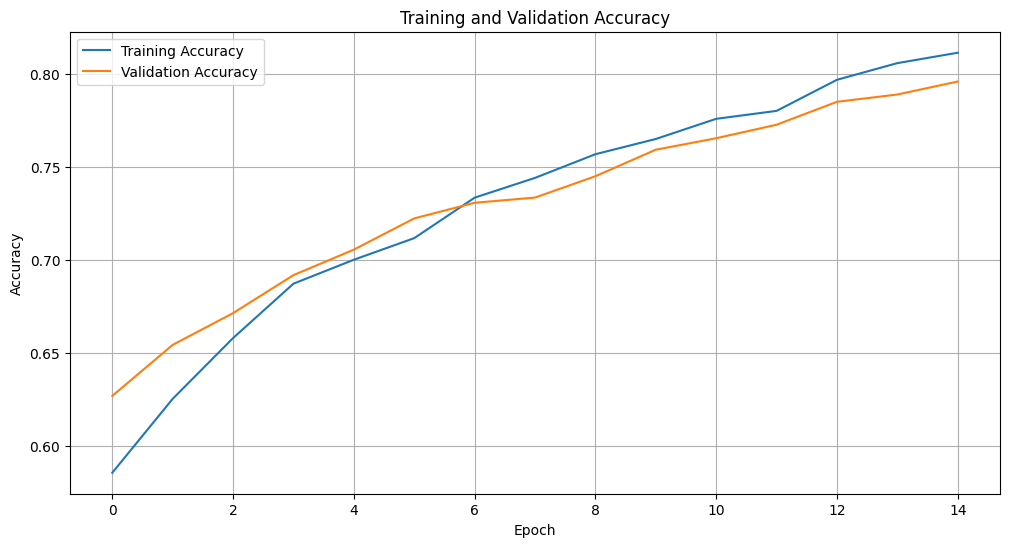

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('training curve efficientnet.png')
plt.show()

In [ ]:
model_efficientnet.save('skin_disease_detection_model.keras')

In [ ]:
model2 = tf.keras.models.load_model(
    '/content/skin_disease_detection_model.keras',
    custom_objects={'preprocess_input': tf.keras.applications.efficientnet.preprocess_input}
)
print("Model loaded successfully.\n")

Model loaded successfully.



In [ ]:
print("Generating predictions...")
true_labels = []
predicted_labels = []


for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)


    true_labels.extend(labels.numpy())
    predicted_labels.extend(np.argmax(preds, axis=1))

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

Generating predictions...


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

print("--- Classification Report ---")
report = classification_report(true_labels, predicted_labels, target_names=class_name, labels=np.arange(len(class_name)))
print(report)


fig = plt.figure(figsize=(10, len(class_name) * 0.5 + 2))
ax = fig.add_subplot(111)
ax.text(0.01, 0.05, report, {'fontsize': 12}, fontproperties = 'monospace')
ax.axis('off')
ax.set_title('Classification Report', fontsize=14, loc='left')
plt.tight_layout()
plt.savefig('classification_report_skin.png')
plt.close(fig)

--- Classification Report ---
                                 precision    recall  f1-score   support

                         Eczema       0.66      0.53      0.59       228
                         Herpes       0.85      0.55      0.67       221
                       Impetigo       0.97      0.99      0.98       258
                      Psoriasis       0.63      0.48      0.54       190
                         Rashes       0.88      0.77      0.82       243
                       Ringworm       0.47      0.71      0.56       208
                        Rosacea       0.87      0.83      0.85       243
                        Scabies       0.66      0.77      0.71       246
                       Vitiligo       0.93      0.77      0.84       158
                           acne       0.80      0.87      0.83       240
                     cellulitis       0.88      0.97      0.93       236
dark_spots or Hyperpigmentation       0.95      0.88      0.91       201
                    

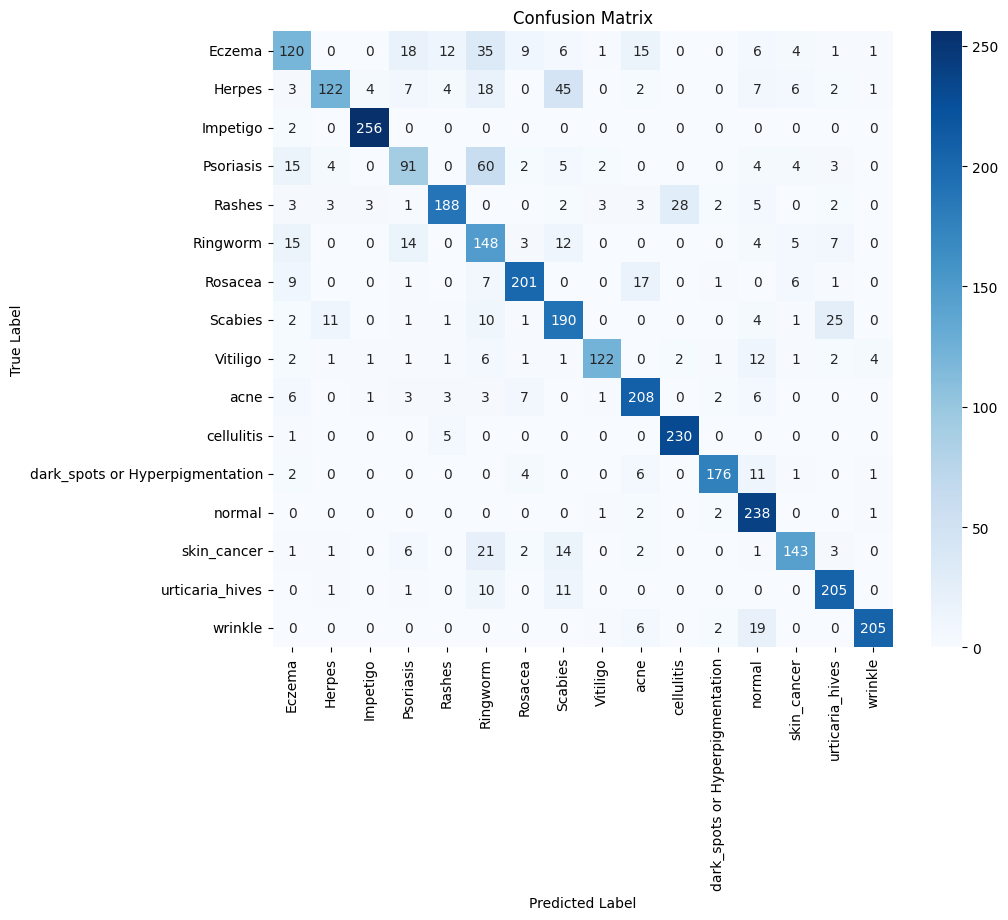

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(class_name)))


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_skin.png')
plt.show()